# **PUC-Rio | Departamento de Engenharia Industrial**
# **ENG 4560: Projeto Integrado VI - Distribuição Física**

---

# **Aula 4 — Modelagem matemática do CVRP (Parte 2)**  
**Prof. Marcello Congro (marcellocongro@puc-rio.br)**

---

## 🎯 Estrutura da Aula:
1. Carregar instância
2. Definir parâmetros logísticos (heterogêneo)
3. Construir modelo matemático
4. Resolver
5. Comparar desempenho
6. Interpretar solução

---

## 🧠 Ideia central desta aula (por que ela existe?)

Na **Aula 3**, construímos um primeiro modelo para o CVRP e vimos um comportamento clássico quando a formulação ainda está incompleta:

- o solver pode encontrar uma solução "ótima" **com subtours** (ciclos desconectados do depósito).

Nesta **Aula 4**, vamos fazer duas melhorias fundamentais **no modelo** (não no solver):

1. **Frota heterogênea** (1 VUC + 3 Fiorinos): aproxima a modelagem da operação real.
2. **MTZ (Miller–Tucker–Zemlin)**: adiciona conectividade global e **elimina subtours**.

⚠️ Mensagem-chave: **mais realismo → mais restrições/variáveis → maior custo computacional**.  
Isso prepara o terreno para discutir escalabilidade, limites de métodos exatos e (nas próximas aulas) heurísticas.

---

## ✅ O que você deve conseguir responder ao final

1. Por que "restrições de grau" (entrar/sair 1x) **não** garantem uma rota conectada ao depósito?
2. O que o MTZ faz *na prática* e por que ele aumenta a dificuldade computacional?
3. Em que sentido a frota heterogênea muda o espaço de decisão do problema?
4. Por que uma solução ótima (MILP) pode ser inviável como decisão gerencial se o tempo de solução for alto?

## **Como trabalhar neste notebook**

Este material foi estruturado como estudo guiado.

Recomenda-se:

1. Ler antes de executar;
2. Discutir em grupo as perguntas indicadas;
3. Observar cuidadosamente os tempos de solução.

Evite executar todas as células de uma vez.

In [ ]:
# =====================================================
# (1) PREPARAÇÃO DO AMBIENTE COMPUTACIONAL
# =====================================================

# Nesta disciplina, o solver é apenas o "motor" de otimização.
# O que determina a qualidade/realismo da solução é o MODELO matemático.

# Aqui instalamos o CBC (open-source) para garantir que o notebook rode.
# Se você tiver Gurobi ou CPLEX configurados, vamos usar mais adiante.

# Pergunta:
# um modelo mais realista será mais fácil ou mais difícil de resolver?

!apt-get update -y
!apt-get install -y coinor-cbc

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,737 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,301 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,538 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packag

In [ ]:
# =====================================================
# (2) UPLOAD DA INSTÂNCIA DESEJADA
# =====================================================

# A instância define o problema: nós (depósito + clientes), demandas,
# distâncias e parâmetros já preparados na Aula 2.

# Boa prática de engenharia: sempre limpar arquivos antigos antes do upload.
# =====================================================

!rm -f *.csv *.npy *.json
from google.colab import files
import os

print("Faça upload dos arquivos da instância")
uploaded = files.upload()

print("Arquivos disponíveis:")
print(os.listdir())

Faça upload dos arquivos da instância


Saving Cvar.npy to Cvar.npy
Saving D.npy to D.npy
Saving nodes.csv to nodes.csv
Saving params.json to params.json
Saving q.npy to q.npy
Saving s.npy to s.npy
Saving Tmov_h.npy to Tmov_h.npy
Arquivos disponíveis:
['.config', 'q.npy', 'Cvar.npy', 'D.npy', 'nodes.csv', 'params.json', 's.npy', 'Tmov_h.npy', 'sample_data']


In [ ]:
# =====================================================
# (3) LEITURA E VALIDAÇÃO DA INSTÂNCIA
# =====================================================

# Antes de modelar, VALIDAMOS os dados.
# Se a base estiver inconsistente, o solver pode:
# - declarar inviabilidade, ou
# - "resolver" algo que não representa a operação real.
#
# Perguntas rápidas (registre suas respostas):
# 1) A demanda total cabe na frota disponível?
# 2) Existem clientes com demanda > capacidade de algum veículo?
# 3) Distâncias e coordenadas parecem plausíveis?
# =====================================================

import numpy as np
import pandas as pd
import json

nodes = pd.read_csv("nodes.csv")
D = np.load("D.npy")
C = np.load("Cvar.npy")
q = np.load("q.npy")
s = np.load("s.npy")

params = json.loads(open("params.json", "r").read())

n = len(nodes)

assert D.shape == (n,n)
assert C.shape == (n,n)
assert q.shape == (n,)
assert s.shape == (n,)
assert nodes.loc[0,"id"] == 0

print(f"Instância carregada: {n-1} clientes + depósito")

Instância carregada: 10 clientes + depósito


In [ ]:
# ======================================================
# (4) PARÂMETROS LOGÍSTICOS - FROTA HETEROGÊNEA
# ======================================================

# Nesta aula, saímos do cenário homogêneo (Aula 3) e aproximamos da operação:
# - dois tipos de veículo (Fiorino e VUC)
# - capacidades diferentes
# - custos fixos diferentes
#
# Interpretação:
# Q[k]  -> capacidade do tipo k (kg)
# f[k]  -> custo fixo diário do tipo k (R$)
# H     -> limite operacional de jornada (h)
# v_kmh -> velocidade média (km/h)
# T     -> matriz de tempos de viagem (h), derivada de D (km)

# Pergunta (importante):
# Quais riscos operacionais surgem quando a jornada NÃO é imposta diretamente no modelo?

#
# Observe que:
# VUC:
# Maior capacidade
# Maior custo fixo

# Fiorino:
# Menor capacidade
# Menor custo
# =====================================================

# Tipos de veículos
vehicle_types = ["FIO", "VUC"]

Q = {
    "FIO": 650.0,
    "VUC": 3000.0
}

f = {
    "FIO": 250.0,
    "VUC": 550.0
}

H = 8.0
v_kmh = 40.0

# Usaremos H=8h como referência OPERACIONAL e faremos
# uma checagem pós-solução por rota/veículo (validação).

T = D / v_kmh

In [ ]:
# =====================================================
# (5) CONSTRUÇÃO DO MODELO
# =====================================================

# Conjuntos típicos:
# N -> nós (0 = depósito; 1..n-1 = clientes)
# C -> clientes
# K -> veículos (nesta aula: veículos individuais, ainda que de tipos distintos)
# A -> arcos (i,j,k): decisão de o veículo k ir de i para j
#
# Atenção:
# - na Aula 3, detectávamos subtours.
# - na Aula 4, vamos ELIMINAR subtours (MTZ).
# =====================================================

from pyomo.environ import *

model = ConcreteModel()

model.N = RangeSet(0, n-1)
model.C = RangeSet(1, n-1)
model.K = Set(initialize=vehicle_types)

model.A = [(i,j,k) for i in range(n)
                     for j in range(n)
                     for k in vehicle_types
                     if i != j]

model.x = Var(model.A, domain=Binary)

# Observação:
# Nesta versão, K representa tipos/decisões de frota (simplificação).
# Uma modelagem mais fiel com 3 Fiorinos + 1 VUC exigiria veículos individuais
# (ex.: K = {FIO1, FIO2, FIO3, VUC1}), aumentando o tamanho do modelo.

In [ ]:
# =====================================================
# (6) VARIÁVEIS AUXILIARES (MTZ)
# =====================================================

# u[i,k] é uma variável auxiliar que impõe uma "ordem" de visita do cliente i
# na rota do veículo k. Ela NÃO mede distância; mede posição relativa.
#
# Intuição:
# - se cada cliente tiver uma posição coerente na sequência,
#   não conseguimos formar um ciclo fechado desconectado do depósito.
#
# Orientação:
# - primeiro implemente a versão TODO (aluno)
# - depois compare com o gabarito
# - e, principalmente, ENTENDA o papel dessa variável.

if hasattr(model, "u"):
    model.del_component(model.u)

model.u = Var(model.C, bounds=(1, n-1))

In [ ]:
# =====================================================
# (7) NÚMERO DE VEÍCULOS POR TIPO
# =====================================================
# Em vez de contar quantas saídas existem do depósito,
# introduzimos uma variável binária y[k].

# y[k] = 1 indica que o veículo foi utilizado.

# Isso representa melhor o custo fixo operacional: o veículo é acionado ou não.

# Número de veículos por tipo
def m_expr(model, k):
    return sum(model.x[0,j,k] for j in model.C)

# Variável binária de ativação do veículo
model.y = Var(model.K, domain=Binary)

# =============================================
# TODO (PREENCHA AQUI):
# Se um veículo sai do depósito, ele deve ser ativado.

def activate_vehicle_rule(model, k):
    return ???????

# TODO (PREENCHA AQUI:)
# Se o veículo retorna ao depósito,
# ele também deve estar ativado.

def activate_return_rule(model, k):
    return ??????
# =============================================

model.activate_vehicle = Constraint(model.K, rule=activate_vehicle_rule)
model.activate_return = Constraint(model.K, rule=activate_return_rule)

In [ ]:
# ============================================================
# (8) DISPONIBILIDADE DE FROTA (REALISMO OPERACIONAL)
# ============================================================
#
# Vamos supor que quiséssemos definir uma quantidade específica de VUCs e Fiorinos para o problema (por exemplo, 1 VUC e 3 Fiorinos)
# Da forma como estruturamos o código, as linhas abaixo são ou não são redundantes? Justifique.

# model.limit_vuc = Constraint(expr = model.y["VUC"] <= 1)
# model.limit_fio = Constraint(expr = model.y["FIO"] <= 3)

In [ ]:
# ============================================================
# (9) FUNÇÃO OBJETIVO
# ============================================================

# Agora otimizamos custo total:
# - custo variável (deslocamento) + custo fixo (ativação de veículo)

# Trade-off típico:
# - usar um VUC (custo fixo maior) pode reduzir o número de veículos e viagens
# - usar Fiorinos (custo fixo menor) pode exigir mais rotas/quilometragem

# Pergunta:
# Se o custo fixo do VUC aumentasse muito, o que você espera que a solução faça?

def obj_rule(model):
    travel_cost = sum(C[i,j] * model.x[i,j,k] for (i,j,k) in model.A)
    fixed_cost = sum(f[k] * model.y[k] for k in model.K)
    return travel_cost + fixed_cost

model.obj = Objective(rule=obj_rule, sense=minimize)

In [ ]:
# ============================================================
# (10) RESTRIÇÕES DE ATENDIMENTO (GRAU)
# ============================================================
# Cada cliente deve ser atendido exatamente UMA vez.
#
# Isso significa duas coisas:
#
# (1) Deve existir exatamente UMA saída do cliente (o veículo sai após atendê-lo).
#
# (2) Deve existir exatamente UMA entrada no cliente (algum veículo chega para atendê-lo).
#
# Essas são chamadas RESTRIÇÕES DE GRAU.
#
# Mesmo garantindo:
#   - uma entrada,
#   - uma saída,
#
# ainda podem existir ciclos desconectados do depósito.
#
# Ou seja:
#
# grau local ≠ conectividade global.
#
# É exatamente isso que o MTZ corrigirá depois.
# ============================================================
# SAÍDA ÚNICA POR CLIENTE
# ============================================================
def out_rule(model, i):

    return sum(
        model.x[i, j, k]
        for j in model.N if j != i
        for k in model.K
    ) == 1

model.out = Constraint(model.C, rule=out_rule)
# ============================================================
# ENTRADA ÚNICA POR CLIENTE
# ============================================================
def in_rule(model, j):

    return sum(
        model.x[i, j, k]
        for i in model.N if i != j
        for k in model.K
    ) == 1

model.inn = Constraint(model.C, rule=in_rule)

### Pergunta rápida

Se cada cliente possui exatamente uma entrada e uma saída,
por que ainda podem existir ciclos desconectados?

Discuta com sua equipe antes de continuar.


In [ ]:
# ============================================================
# (11) BALANÇO NO DEPÓSITO
# ============================================================

# Para cada veículo k:
# - o número de saídas do depósito deve igualar o número de retornos
#
# Importante:
# Isso garante consistência no depósito, mas ainda NÃO impede ciclos desconectados
# entre clientes (subtours).

def depot_balance(model, k):
    return sum(model.x[0,j,k] for j in model.C) == \
           sum(model.x[i,0,k] for i in model.C)

model.depot_balance = Constraint(model.K, rule=depot_balance)

# Cada veículo pode iniciar no máximo uma rota.
# Isso evita que o mesmo veículo opere múltiplas rotas independentes.

def single_departure_rule(model, k):
    return sum(model.x[0, j, k] for j in model.C) <= 1

model.single_departure = Constraint(model.K, rule=single_departure_rule)

# Observação:
# Sem esta restrição, o modelo poderia permitir que o mesmo veículo
# iniciasse múltiplas rotas independentes a partir do depósito.

In [ ]:
# ============================================================
# (12) CAPACIDADE AGREGADA HETEROGÊNEA
# ============================================================
# Aqui fazemos um check agregado:
# - demanda total <= capacidade total disponibilizada pelos veículos ativados

# Atenção:
# Esta restrição NÃO impede que uma rota individual transporte
# mais carga do que a capacidade do veículo.
#
# Atenção:
# Isso NÃO garante que cada veículo individualmente respeite sua capacidade.
# (isso exigiria restrições por veículo/rota — o que aumenta ainda mais o modelo)

def capacity_rule(model):
    total_demand = sum(q[i] for i in range(1,n))
    total_capacity = sum(Q[k] * model.y[k] for k in model.K)
    return total_demand <= total_capacity

model.capacity = Constraint(rule=capacity_rule)

In [ ]:
# ============================================================
# (13) CONSERVAÇÃO DE FLUXO POR VEÍCULO (ESSENCIAL NO HETEROGÊNEO)
# ============================================================
# Para cada veículo k e cliente i:
# - tudo que entra em i pelo veículo k deve sair de i pelo mesmo veículo k
#
# Isso força a rota do veículo a ser "contínua localmente".
#
# Mas, de novo:
# conectividade GLOBAL ainda não está garantida → subtours podem surgir.

# ===============================================================
# TODO (ALUNO): implementar fluxo por tipo
# para todo i em C e todo k em K:
# sum_j x[i,j,k] - sum_j x[j,i,k] == 0

def flow_by_type_rule(model, i, k):
  return ????
# ===============================================================

model.flow_by_type = Constraint(model.C, model.K, rule=flow_by_type_rule)

In [ ]:
# ============================================================
# (14) MTZ — ELIMINAÇÃO DE SUBTOURS
# ============================================================
# Agora adicionamos a restrição que faltava na Aula 3: conectividade global.

# Leia com calma:
# u[i] - u[j] + M * x[i,j] <= M-1 (variações equivalentes)

# Interpretação:
# Se o arco i->j é usado, então j deve estar "depois" de i na ordem.

# Perguntas:
# 1) Por que precisamos de um M grande?
# 2) O que acontece se M for pequeno demais?
# 3) Por que isso evita subtours?

# MTZ - ELIMINAÇÃO DE SUBTOURS
# TODO (ALUNO): Implementar restrição MTZ
# u_i - u_j + (n-1)*sum_k x[i,j,k] <= n-2

# Utilizamos uma única variável u[i] compartilhada entre veículos.
# Essa é uma simplificação para reduzir o tamanho do modelo.
#
# Formulações VRP completas podem utilizar u[i,k],
# aumentando significativamente o número de variáveis e restrições.

if hasattr(model, "mtz"):
    model.del_component(model.mtz)

# ===================================
# TODO (ALUNO): Termine de preencher a função
def mtz_rule(model, i, j):
    if i == j:
        return Constraint.Skip  # Auto-arcos não fazem sentido na ordem MTZ
    return ?????
# ===================================

model.mtz = Constraint(model.C, model.C, rule=mtz_rule)

In [ ]:
# ============================================================
# (15) COMPLEXIDADE — MEDINDO O TAMANHO DO PROBLEMA
# ============================================================

# Queremos ter noção de:
# - número de variáveis binárias
# - número de clientes
# - número de tipos/veículos

# Compare com a Aula 3:
# só acrescentar dimensão de veículo + MTZ já muda muito a escala.

print("Variáveis binárias:", len(model.A))
print("Clientes:", n-1)
print("Tipos de veículos:", vehicle_types)
print("Número de restrições:", len(list(model.component_data_objects(Constraint))))

Variáveis binárias: 220
Clientes: 10
Tipos de veículos: ['FIO', 'VUC']
Número de restrições: 141


In [ ]:
# ============================================================
# (16) ESCOLHA DO SOLVER
# ============================================================
# Você pode rodar com CBC, mas para instâncias maiores o Gurobi tende a ser
# significativamente mais rápido.
#
# Observação pedagógica:
# Solver "melhor" ajuda, mas não anula o crescimento combinatório.

# ESCOLHA DO SOLVER
#=======================================================
# PARA RODAR CORRETAMENTE O GUROBI

!pip install gurobipy
import gurobipy

os.environ["GRB_WLSACCESSID"] = ""     # Insira a sua chave aqui
os.environ["GRB_WLSSECRET"] = ""       # Insira a sua chave aqui
os.environ["GRB_LICENSEID"] = ""       # Insira a sua chave aqui
#=======================================================

from pyomo.opt import SolverFactory

SOLVER_NAME = "gurobi_direct"  # ou gurobi_direct / cplex

solver = SolverFactory(SOLVER_NAME)

if not solver.available():
    raise RuntimeError(f"Solver {SOLVER_NAME} não disponível.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 62.2 MB/s eta 0:00:00


In [ ]:
# ============================================================
# (17) RESOLUÇÃO — MEÇA O TEMPO
# ============================================================
# Boa prática:
# Sempre registre tempo e status de solução.

# Pergunta:
# O tempo aumentou em relação à Aula 3? Por quê?

import time

start_time = time.time()
results = solver.solve(model)
end_time = time.time()

print("Status:", results.solver.status)
print("Termination:", results.solver.termination_condition)
print("Tempo:", end_time - start_time)
print("Custo total:", value(model.obj))

for k in model.K:
    print(f"Veículos tipo {k}:", value(model.y[k]))

# ===================================
# TODO (ALUNO): comente o MTZ e rode novamente.
# O que apareceu?
# ===================================

Status: ok
Termination: optimal
Tempo: 4.663939952850342
Custo total: 722.9807851623269
Veículos tipo FIO: 0.0
Veículos tipo VUC: 1.0


In [ ]:
# ============================================================
# (18) EXTRAÇÃO DOS ARCOS SELECIONADOS
# ============================================================
# Após resolver, extraímos os arcos (i,j,k) com x=1.

# Isso é a "solução" em linguagem do modelo.
# Agora precisamos convertê-la em rotas compreensíveis.

selected_arcs = [(i,j,k) for (i,j,k) in model.A
                 if value(model.x[i,j,k]) > 0.5]

print("Arcos selecionados:", selected_arcs[:20])

Arcos selecionados: [(0, 5, 'VUC'), (1, 9, 'VUC'), (2, 6, 'VUC'), (3, 0, 'VUC'), (4, 7, 'VUC'), (5, 2, 'VUC'), (6, 4, 'VUC'), (7, 10, 'VUC'), (8, 3, 'VUC'), (9, 8, 'VUC'), (10, 1, 'VUC')]


In [ ]:
# ============================================================
# (19) RECONSTRUÇÃO DAS ROTAS POR VEÍCULO
# ============================================================
# Transformamos a lista de arcos em sequência (rota) por veículo.
#
# Atenção:
# - este passo é pós-processamento (não é otimização)
# - é essencial para validar operacionalmente.

from collections import defaultdict

succ = defaultdict(dict)

for (i,j,k) in selected_arcs:
    succ[k][i] = j

routes = []

for k in model.K:
    starts = [j for (i,j,kk) in selected_arcs if i == 0 and kk == k]

    for start in starts:
        route = [0, start]
        current = start

        while current != 0:
            next_node = succ[k].get(current, None)
            if next_node is None:
                break
            route.append(next_node)
            current = next_node

        routes.append((k, route))

In [ ]:
# ============================================================
# (20) VALIDAÇÃO PÓS-SOLUÇÃO — JORNADA POR VEÍCULO/ROTA
# ============================================================
# Como a jornada NÃO foi imposta no MIP,
# validamos aqui se cada rota/veículo respeita H = 8h.
#
# Tempo total da rota = (tempo de deslocamento) + (tempo de serviço)
# ============================================================

def route_time(route):
    # Tempo de deslocamento ao longo dos arcos da rota
    t_mov = 0.0
    for a in range(len(route) - 1):
        i = route[a]
        j = route[a+1]
        t_mov += T[i, j]

    # Tempo de serviço (somente clientes, exclui depósito)
    clients = [node for node in route if node != 0]
    t_serv = sum(s[i] for i in clients)

    return t_mov + t_serv, t_mov, t_serv, clients

print(f"Limite operacional (referência): H = {H:.2f} h\n")

violations = 0
all_visited = set()

for r_id, (k, r) in enumerate(routes, start=1):
    t_total, t_mov, t_serv, clients = route_time(r)
    all_visited.update(clients)

    status = "OK" if t_total <= H + 1e-6 else "VIOLA"
    if status == "VIOLA":
        violations += 1

    print(f"[{k}] Rota {r_id}: tempo total = {t_total:.2f} h (mov={t_mov:.2f}, serv={t_serv:.2f}) -> {status}")

print(f"\nTotal de rotas que violam H: {violations}")

# Checagem de atendimento (sanidade): todos os clientes aparecem em alguma rota?
missing = set(range(1, n)) - all_visited
if missing:
    print("\nATENÇÃO: Existem clientes que não apareceram nas rotas reconstruídas:", sorted(missing))
else:
    print("\nChecagem de atendimento: OK (todos os clientes aparecem nas rotas).")

Limite operacional (referência): H = 8.00 h

[VUC] Rota 1: tempo total = 5.38 h (mov=2.88, serv=2.50) -> OK

Total de rotas que violam H: 0

Checagem de atendimento: OK (todos os clientes aparecem nas rotas).


In [ ]:
# Métricas simples da rota (interpretação da solução):
# 1) número de clientes atendidos nesta rota
# 2) tempo médio total por cliente
# 3) tempo médio de serviço por cliente
# 4) tempo médio de deslocamento por cliente
# 5) percentual do tempo em deslocamento (vs. serviço)
#
# Dicas:
# - clients é uma lista com os clientes atendidos nesta rota (sem o depósito).
# - cuidado com divisão por zero (rotas degeneradas).
# - percentual = (tempo_deslocamento / tempo_total) * 100
# ============================================================

#GABARITO:
n_clients = len(clients)

if n_clients > 0:
    avg_total = t_total / n_clients
    avg_serv  = t_serv  / n_clients
    avg_mov   = t_mov   / n_clients
    pct_mov   = 100.0 * (t_mov / t_total) if t_total > 1e-9 else 0.0
else:
    avg_total = avg_serv = avg_mov = 0.0
    pct_mov = 0.0

print(f"    Clientes atendidos: {n_clients}")
print(f"    Tempo médio total por cliente: {avg_total:.2f} h/cliente")
print(f"    Tempo médio de serviço por cliente: {avg_serv:.2f} h/cliente")
print(f"    Tempo médio de deslocamento por cliente: {avg_mov:.2f} h/cliente")
print(f"    % tempo em deslocamento: {pct_mov:.1f}%")

    Clientes atendidos: 10
    Tempo médio total por cliente: 0.54 h/cliente
    Tempo médio de serviço por cliente: 0.25 h/cliente
    Tempo médio de deslocamento por cliente: 0.29 h/cliente
    % tempo em deslocamento: 53.6%


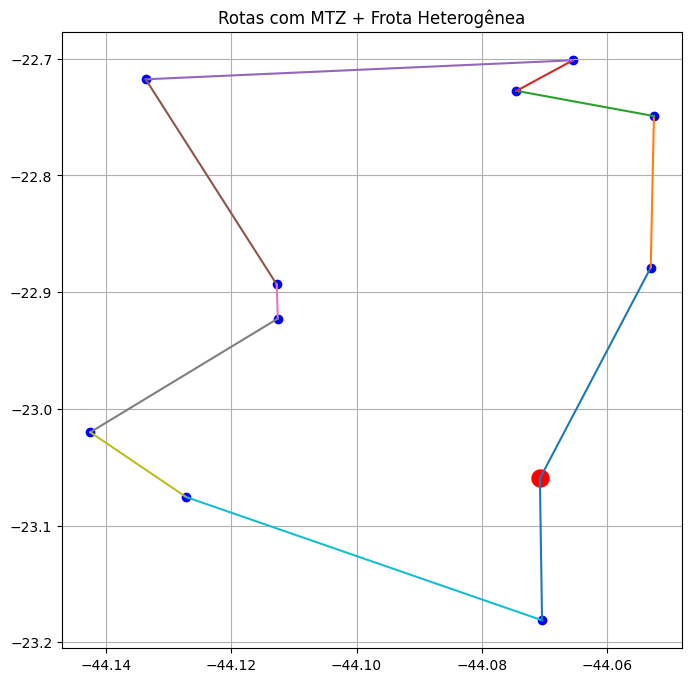

In [ ]:
# ============================================================
# (21) VISUALIZAÇÃO
# ============================================================
# É uma ferramenta de validação:
# - existe rota desconectada?
# - todos saem e retornam ao depósito?
# - MTZ funcionou (subtours desapareceram)?

# Antes de seguir, responda:
# Você consegue identificar algum ciclo sem depósito?

import matplotlib.pyplot as plt

x_coords = nodes["lon"].values
y_coords = nodes["lat"].values

plt.figure(figsize=(8,8))

plt.scatter(x_coords[1:], y_coords[1:], color='blue')
plt.scatter(x_coords[0], y_coords[0], color='red', s=150)

for k, route in routes:
  for i in range(len(route)-1):
        i_node = route[i]
        j_node = route[i+1]
        plt.plot([x_coords[i_node], x_coords[j_node]],
                 [y_coords[i_node], y_coords[j_node]])

plt.title("Rotas com MTZ + Frota Heterogênea")
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# (22) CHECK OPERACIONAL (AGREGADO)
# ============================================================
# Aqui verificamos coerência operacional, mesmo que de forma agregada:
# - demanda total vs capacidade total ativada
# - tempos de deslocamento e serviço
# - orçamento de horas (H * veículos ativados)
#
# Mensagem-chave:
# Resolver MILP não encerra o trabalho. Operação precisa validar.

from pyomo.environ import value

total_demand = sum(q[i] for i in range(1,n))
cap_total = sum(Q[k]*value(model.y[k]) for k in vehicle_types)

Tmov_sol = sum(T[i,j]*value(model.x[i,j,k]) for (i,j,k) in model.A)
Tserv = sum(s[i] for i in range(1,n))

print("=== CHECK OPERACIONAL (AGREGADO) ===")
print(f"Demanda total (kg): {total_demand:.1f}")
print(f"Capacidade total disponível (kg): {cap_total:.1f}")
print(f"Tempo deslocamento da solução (h): {Tmov_sol:.2f}")
print(f"Tempo de serviço total (h): {Tserv:.2f}")
print(f"Tempo total (h): {Tmov_sol+Tserv:.2f}")
print("m[VUC] =", value(model.y["VUC"]), "| m[FIO] =", value(model.y["FIO"]))
print("Termination condition:", results.solver.termination_condition)
print("\nObs.: H=8h NÃO foi imposto no MIP. A jornada está sendo validada por rota/veículo.")

=== CHECK OPERACIONAL (AGREGADO) ===
Demanda total (kg): 2562.8
Capacidade total disponível (kg): 3000.0
Tempo deslocamento da solução (h): 2.88
Tempo de serviço total (h): 2.50
Tempo total (h): 5.38
m[VUC] = 1.0 | m[FIO] = 0.0
Termination condition: optimal

Obs.: H=8h NÃO foi imposto no MIP. A jornada está sendo validada por rota/veículo.


In [ ]:
# ============================================================
# (23) EXPERIMENTO COMPUTACIONAL CONTROLADO
# ============================================================
# Agora vamos impor um limite de tempo ao solver.
# Objetivo:
# - Observar como o solver retorna solução incumbente
# - Avaliar o gap
# - Entender o trade-off entre tempo e qualidade
# ============================================================

solver.options.clear()
USE_TIMELIMIT = True
TL_SECONDS = 300  # 5 minutos (ajuste se quiser)

if USE_TIMELIMIT:

    print(f"\nResolvendo com limite de {TL_SECONDS} segundos...\n")

    if SOLVER_NAME.startswith("gurobi_direct"):
        solver.options["TimeLimit"] = TL_SECONDS

    elif SOLVER_NAME.startswith("cplex"):
        solver.options["timelimit"] = TL_SECONDS

    elif SOLVER_NAME == "cbc":
        solver.options["seconds"] = TL_SECONDS

    import time
    start_time = time.time()
    results = solver.solve(model, tee=True)
    end_time = time.time()

    elapsed = end_time - start_time

    print("\nStatus:", results.solver.status)
    print("Termination condition:", results.solver.termination_condition)
    print(f"Tempo de solução: {elapsed:.2f} segundos")

    try:
        print("Custo incumbente:", value(model.obj))
    except:
        print("Nenhuma solução incumbente disponível.")


Resolvendo com limite de 300 segundos...

Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 141 rows, 232 columns and 1268 nonzeros (Min)
Model fingerprint: 0xb884c1ff
Model has 222 linear objective coefficients
Variable types: 10 continuous, 222 integer (222 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+03]
  Objective range  [5e+00, 6e+02]
  Bounds range     [1e+00, 1e+01]
  RHS range        [1e+00, 3e+03]

Found heuristic solution: objective 1203.4506756
Presolve removed 5 rows and 1 columns
Presolve time: 0.01s
Presolved: 136 rows, 231 columns, 1242 nonzeros
Variable types: 10 continuous, 221 integer (221 binary)

Root relaxation: objective 6.661802e+02, 28 iterations, 0.00 seconds (0.0

## **Para Casa**: Análises de sensibilidade

In [ ]:
# ============================================================
# (24) EXPERIMENTOS GUIADOS - ANÁLISE DE SENSIBILIDADE
# ============================================================
# ============================================================
# SALVANDO PARÂMETROS ORIGINAIS
# ============================================================

Q_original = Q.copy()
f_original = f.copy()

# ============================================================
# EXPERIMENTO 1 — CUSTO FIXO DO VUC
# ============================================================

# ============================================================
# TODO (ALUNO):
# aumente custo fixo do VUC.

f["VUC"] = XXXX     # Modifique aqui
# ============================================================

results = solver.solve(model)

print("Novo custo:", value(model.obj))

for k in model.K:
    print(k, value(model.y[k]))

# ============================================================
# EXPERIMENTO 2 — CAPACIDADE DO VUC
# ============================================================

Q["VUC"] = XXXX       # Modifique aqui

results = solver.solve(model)

print("Novo custo:", value(model.obj))

# ============================================================
# RESET
# ============================================================

Q = Q_original.copy()
f = f_original.copy()

print("Parâmetros restaurados.")

print(len(model.A))
print(len(list(model.component_data_objects(Constraint))))

Responda brevemente às perguntas abaixo:

1. Por que as restrições de grau não garantem conectividade global?

2. Como o MTZ elimina subtours?

3. Qual foi o impacto computacional da inclusão do MTZ?

4. Por que a frota heterogênea aumenta a complexidade?

5. O modelo garante viabilidade individual por veículo?

6. O que significa resolver até ótimo?

7. Em um sistema real, você aguardaria a prova de otimalidade?

8. Qual modelo você adotaria na prática?

9. O tipo de solver impacta na qualidade da solução? Por quê?


- Na Aula 3, vimos que o solver pode gerar subtours porque o modelo não impunha conectividade global.  

- Na Aula 4, o MTZ corrige isso, mas aumenta a dificuldade computacional, motivando a inclusão de limites de tempo ou utilização de outros métodos para resolver o problema (heurísticas e metaheurísticas).